<br>

# MNIST-Predictive-Pipeline 

## Miniprojeto Módulo 2

<br>

### Fase 1: Carregamento e Análise Exploratória de Imagens (EDA)

<br>

In [1]:
# Importando bibliotecas

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.utils import resample
import time
from IPython.display import display
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import visualkeras
from keras.utils import plot_model
from IPython.display import Image
from keras.callbacks import EarlyStopping

In [2]:
# Carregando dataset MNIST

print("Baixando o dataset MNIST...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
print("Finalizou o processo de baixar o dataset MNIST!")

# Separando as features da variável alvo
X, y = mnist.data, mnist.target

# Exibindo a dimensionalidade da matriz X e do vetor y
print(f"Dimensionalidade de X (Features): {X.shape}")
print(f"Dimensionalidade de y (Rótulos): {y.shape}")

Baixando o dataset MNIST...
Finalizou o processo de baixar o dataset MNIST!
Dimensionalidade de X (Features): (70000, 784)
Dimensionalidade de y (Rótulos): (70000,)


Separação Antecipada de Features (X) e Variável Alvo (y):

A separação imediata da base de dados entre a matriz de características ($X$, representando os pixels) e o vetor de rótulos ($y$, representando as classes) logo após o carregamento é uma boa prática arquitetural em Machine Learning, justificada por dois motivos técnicos principais:

1. Proteção e Isolamento no Pré-processamento: Garante que as transformações matemáticas exigidas na Fase 2 (como a normalização das features para a escala de 0.0 a 1.0) sejam aplicadas estritamente aos dados de entrada ($X$). Manter as variáveis separadas evita o risco de corromper acidentalmente os rótulos reais ($y$) durante operações matriciais.  

2. Requisito para Divisão Estratificada: Funções de particionamento, como o train_test_split da biblioteca scikit-learn, exigem que os dados e os rótulos sejam passados como argumentos distintos para sincronizar o embaralhamento. Além disso, ter o vetor $y$ isolado no escopo global é um pré-requisito para alimentar o parâmetro de estratificação (stratify=y), assegurando a proporcionalidade correta das classes (dígitos de 0 a 9) nos conjuntos de treino, validação e teste.

Distribuição das amostras por classe (dígito):
Dígito 0: 6903 imagens
Dígito 1: 7877 imagens
Dígito 2: 6990 imagens
Dígito 3: 7141 imagens
Dígito 4: 6824 imagens
Dígito 5: 6313 imagens
Dígito 6: 6876 imagens
Dígito 7: 7293 imagens
Dígito 8: 6825 imagens
Dígito 9: 6958 imagens


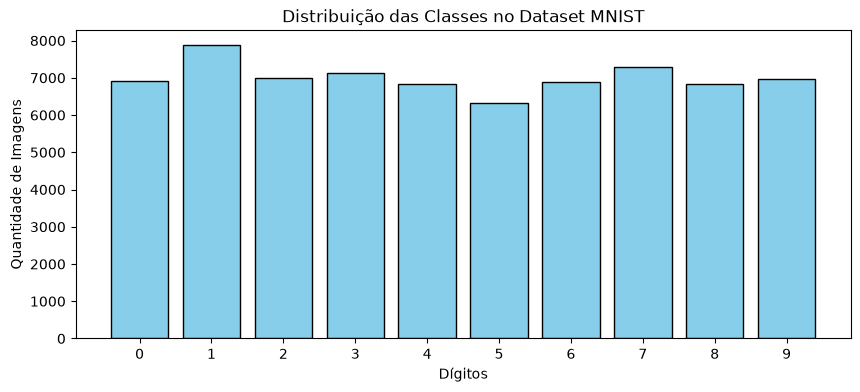

In [3]:
# Verificando balanceamento do dataset

# Analisando a distribuição das classes (dígitos de 0 a 9)
classes, contagens = np.unique(y, return_counts=True)

print("Distribuição das amostras por classe (dígito):")
for classe, contagem in zip(classes, contagens):
    print(f"Dígito {classe}: {contagem} imagens")

# Visualização gráfica
plt.figure(figsize=(10, 4))
plt.bar(classes, contagens, color='skyblue', edgecolor='black')
plt.title("Distribuição das Classes no Dataset MNIST")
plt.xlabel("Dígitos")
plt.ylabel("Quantidade de Imagens")
plt.show()

In [4]:
# Calculando a dispersão estatística da distribuição de classes
media_amostras = np.mean(contagens)
desvio_padrao = np.std(contagens)
coeficiente_variacao = (desvio_padrao / media_amostras) * 100

print(f"Média de amostras por classe: {media_amostras:.0f}")
print(f"Desvio Padrão: {desvio_padrao:.2f}")
print(f"Coeficiente de Variação (CV): {coeficiente_variacao:.2f}%")

Média de amostras por classe: 7000
Desvio Padrão: 378.82
Coeficiente de Variação (CV): 5.41%


Um coeficiente de variação igual a 5.41% é considerado um indicador de baixa dispersão e alta homogeneidade estrutural. Assim, confirma-se que o dataset está balanceado.

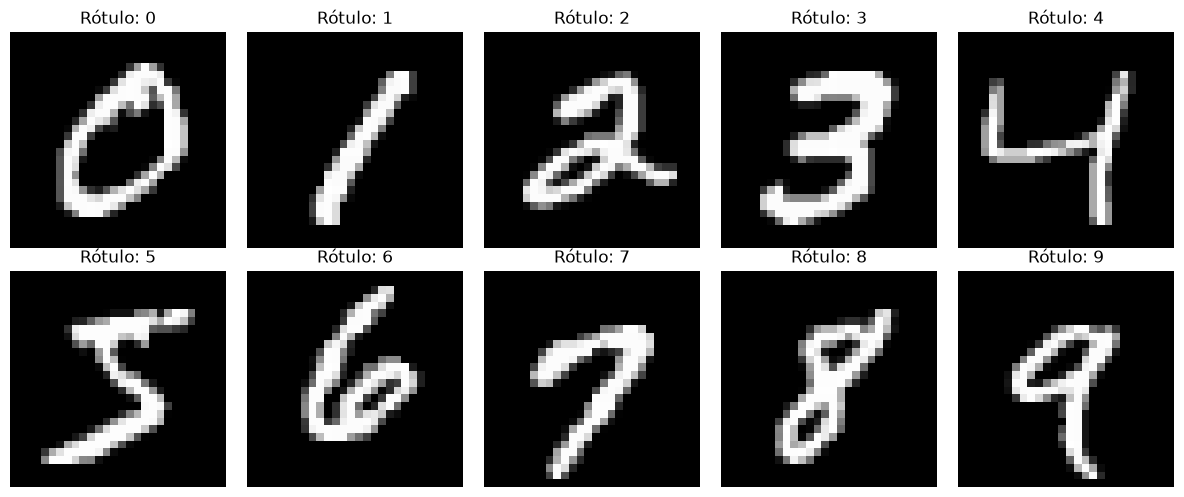

In [5]:
# Exemplos de imagens de cada dígito com seus respectivos rótulos

# Criando uma figura com 2 linhas e 5 colunas
fig, axes = plt.subplots(2, 5, figsize=(12, 5))

# Iterando sobre os dígitos de 0 a 9 para buscar o primeiro exemplo de cada
for classe in range(10):
    # Encontra o índice da primeira ocorrência da classe atual
    indice_imagem = np.where(y == str(classe))[0][0]
    
    # Extrai o vetor de 784 features e remodela para matriz 28x28
    imagem_28x28 = X[indice_imagem].reshape(28, 28)
    
    # Define a posição do subplot (linha e coluna)
    linha = classe // 5
    coluna = classe % 5
    
    # Plota a imagem em escala de cinza
    axes[linha, coluna].imshow(imagem_28x28, cmap='gray')
    axes[linha, coluna].set_title(f"Rótulo: {classe}")
    axes[linha, coluna].axis('off')

plt.tight_layout()
plt.show()

### Interpretação da Estrutura dos Dados


<u>Escala de Intensidade de Pixels (0 a 255)</u>

As imagens do dataset MNIST são monocromáticas (escala de cinza). Computacionalmente, isso significa que cada pixel não possui múltiplos canais de cor (como o RGB), mas sim um único valor numérico inteiro que varia de 0 a 255. Nesta escala de intensidade matemática:

1. O valor 0 representa a ausência total de luz (preto absoluto, geralmente o fundo da imagem).
2. O valor 255 representa a intensidade luminosa máxima (branco absoluto, geralmente o traço principal do dígito).
3. Os valores intermediários (1 a 254) formam as transições suaves e as bordas (tons de cinza).


<u>Representação Vetorial (Transformação de $28\times28$ para 784 features)</u>

Embora a natureza geométrica original de cada imagem seja uma grade bidimensional (uma matriz de 28 linhas por 28 colunas), os algoritmos clássicos de Machine Learning (como SVM e Random Forest) exigem que os dados de entrada sejam unidimensionais.
Para resolver isso, a matriz $28\times28$ passa por um processo de "achatamento" (flattening), onde as linhas de pixels são concatenadas lado a lado. Como $28 \times 28 = 784$, o resultado é um único vetor contendo 784 posições. Portanto, cada "feature" (coluna no nosso conjunto $X$) representa a intensidade de luz de um pixel específico localizado em um ponto exato do desenho original. 

<br>

### Fase 2: Pipeline de Pré-processamento e Divisão dos Dados

<br>

In [6]:
# Como vamos testar alguns hiperparâmetros no treinamento dos modelos,
# optou-se por separar os dados de validação dos dados de teste a fim de evitar vazamento de dados

# Divisão Estratificada (80% Treino, 20% Teste)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    stratify=y, 
    random_state=42
)

print("--- DIVISÃO DOS DADOS ---")
print(f"Treino (80%): {X_train.shape[0]} amostras")
print(f"Teste (20%): {X_test.shape[0]} amostras")

--- DIVISÃO DOS DADOS ---
Treino (80%): 56000 amostras
Teste (20%): 14000 amostras


In [7]:
# Normalização / Escalonamento para o intervalo [0.0, 1.0]
X_train_norm = X_train / 255.0
X_test_norm = X_test / 255.0

print("\n--- NORMALIZAÇÃO ---")
print(f"Valor máximo original (Treino): {X_train.max()}")
print(f"Valor máximo normalizado (Treino): {X_train_norm.max()}")


--- NORMALIZAÇÃO ---
Valor máximo original (Treino): 255
Valor máximo normalizado (Treino): 1.0


### A Importância da Normalização

A etapa de normalização dos pixels (redimensionamento para o intervalo contínuo de 0.0 a 1.0) é um pré-requisito matemático crucial para o desempenho dos algoritmos de aprendizado de máquina escolhidos:

1. Convergência de Modelos de Otimização e Redes Neurais: Modelos que dependem do algoritmo de Gradiente Descendente (como a Regressão Logística e o Perceptron Multicamadas - MLP) convergem de forma muito mais eficiente quando as variáveis de entrada estão em uma escala padronizada e pequena. Valores não normalizados (como 255) causam passos oscilantes e desproporcionais na atualização dos pesos, podendo impedir que o modelo alcance o mínimo global da função de perda.

2. Modelos Baseados em Distâncias Métricas: Caso utilizemos algoritmos que calculam similaridade espacial (como o KNN ou SVM), a normalização é obrigatória. Como os cálculos dependem da Distância Euclidiana entre os pontos, variáveis não escalonadas distorcem a métrica, prejudicando a capacidade geométrica do modelo de separar as classes no hiperplano.

<br>

### Fase 3: Implementação e Treinamento dos 3 Modelos

<br>

### Modelos Clássicos

In [8]:
# # 1. Configuração do dicionário de modelos clássicos e seus hiperparâmetros
# modelos_classicos = {
#     "Regressão Logística": {
#         "estimador": LogisticRegression(solver='saga', random_state=42),
#         "parametros": {
#             "C": [0.1, 1.0],
#             "max_iter": [100, 200]
#         }
#     },
#     "Random Forest": {
#         "estimador": RandomForestClassifier(random_state=42),
#         "parametros": {
#             "n_estimators": [50, 100],
#             "max_depth": [10, None]
#         }
#     }
# }

# melhores_modelos = {}

# print("--- TREINAMENTO DE MODELOS CLÁSSICOS (GridSearchCV) ---")

# # 2. Laço de treinamento e busca automatizada
# for nome, config in modelos_classicos.items():
#     print(f"\nIniciando busca para: {nome}...")
#     inicio = time.time()
    
#     # cv=3 divide o treino em 3 dobras para validação cruzada interna
#     grid = GridSearchCV(config["estimador"], config["parametros"], cv=3, n_jobs=-1, verbose=1)
#     grid.fit(X_train_norm, y_train)
    
#     fim = time.time()
#     tempo_execucao = (fim - inicio) / 60
    
#     melhores_modelos[nome] = grid.best_estimator_
    
#     print(f"Melhores parâmetros: {grid.best_params_}")
#     print(f"Tempo de treinamento: {tempo_execucao:.2f} minutos")

In [9]:
# Na tentativa inicial de realizar o treinamento com validação cruzada em todo dataset de treino, o modelo travou.
# Assim, optou-se por realizar uma subamostragem apenas para encontrar os melhores hiperparâmetros.
# O treinamento final será feito com o dataset de treino completo.

# 1. Subamostragem para Busca (10k)
print("--- 1. CRIANDO SUBAMOSTRA PARA GRIDSEARCH ---") 
X_busca, y_busca = resample(
    X_train_norm, y_train,
    replace=False,      # <--- Garante imagens únicas
    n_samples=10000,    # <--- Extrai 10.000 amostras mantendo a proporção exata de cada dígito
    stratify=y_train,   # <--- Garante que a divisão entre dados de treino e teste mantenha a mesma proporção das classes
    random_state=42     # <--- Semente de aleatoriedade
)
print(f"Tamanho da amostra: {X_busca.shape[0]} imagens únicas\n")

# 2. Configuração dos Modelos Clássicos
modelos_classicos = {
    "Regressão Logística": {
        "estimador": LogisticRegression(solver='lbfgs', random_state=42),    # A troca do solver 'saga' pelo 'lbfgs' foi realizada para otimizar o custo computacional
        "parametros": {
            "C": [0.1, 1.0],
            "max_iter": [50, 100]
        }
    },
    "Random Forest": {
        "estimador": RandomForestClassifier(random_state=42),
        "parametros": {
            "n_estimators": [50, 100],
            "max_depth": [10, None]
        }
    }
}

melhores_modelos = {}

# 3. Laço Único: Busca, Histórico e Seleção
print("--- 2. OTIMIZAÇÃO DE HIPERPARÂMETROS (Subamostra) ---")

for nome, config in modelos_classicos.items():
    print(f"\n>> Analisando: {nome}...")
    inicio = time.time()
    
    # verbose=0 silencia os logs poluídos do Scikit-Learn
    grid = GridSearchCV(config["estimador"], config["parametros"], cv=3, n_jobs=2, verbose=0)
    grid.fit(X_busca, y_busca)
    
    fim = time.time()
    melhores_modelos[nome] = grid.best_estimator_
    
    print(f"Melhores parâmetros: {grid.best_params_}")
    print(f"Tempo de busca: {(fim - inicio) / 60:.2f} minutos")
    
    # Extração imediata do histórico (sem retreinar)
    df_resultados = pd.DataFrame(grid.cv_results_)
    colunas_param = [col for col in df_resultados.columns if col.startswith('param_')]
    colunas_exibicao = colunas_param + ['mean_fit_time', 'mean_test_score', 'rank_test_score']
    df_tabela = df_resultados[colunas_exibicao].sort_values(by='rank_test_score')
    
    display(df_tabela)

# 4. Treinamento Definitivo
print("\n--- 3. TREINAMENTO FINAL NA BASE COMPLETA (80%) ---")
modelos_treinados = {}

for nome, modelo in melhores_modelos.items():
    print(f"\n\nTreinando {nome} com os hiperparâmetros campeões...")
    inicio = time.time()
    
    modelo.fit(X_train_norm, y_train)
    
    fim = time.time()
    modelos_treinados[nome] = modelo
    print(f"{nome} concluído em {(fim - inicio) / 60:.2f} minutos.")
    

--- 1. CRIANDO SUBAMOSTRA PARA GRIDSEARCH ---
Tamanho da amostra: 10000 imagens únicas

--- 2. OTIMIZAÇÃO DE HIPERPARÂMETROS (Subamostra) ---

>> Analisando: Regressão Logística...
Melhores parâmetros: {'C': 0.1, 'max_iter': 100}
Tempo de busca: 0.43 minutos


,param_C,param_max_iter,mean_fit_time,mean_test_score,rank_test_score
1,0.1,100,2.833535,0.907000,1
0,0.1,50,1.907458,0.906799,2
2,1.0,50,1.732587,0.899600,3
3,1.0,100,2.405070,0.895800,4



>> Analisando: Random Forest...
Melhores parâmetros: {'max_depth': None, 'n_estimators': 100}
Tempo de busca: 0.56 minutos


,param_max_depth,param_n_estimators,mean_fit_time,mean_test_score,rank_test_score
3,None,100,5.144927,0.9427,1
2,None,50,2.641082,0.9369,2
1,10,100,4.410949,0.9349,3
0,10,50,2.358014,0.9294,4



--- 3. TREINAMENTO FINAL NA BASE COMPLETA (80%) ---


Treinando Regressão Logística com os hiperparâmetros campeões...


c:\Users\Raphael\Documents\MNIST-Predictive-Pipeline\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Regressão Logística concluído em 0.41 minutos.


Treinando Random Forest com os hiperparâmetros campeões...
Random Forest concluído em 0.95 minutos.


### Documentação - Treinamento dos modelos clássicos

A tentativa inicial de rodar todas as combinações de hiperparâmetros na base completa (56.000 imagens) exigiu muito processamento e travou o sistema. A solução estruturada no código divide o processo em duas grandes etapas: uma busca rápida por configurações ideais em uma amostra menor e o treinamento definitivo na base completa.

Passo 1: Subamostragem Inteligente

- A função `resample` cria um "mini-dataset" de apenas 10.000 imagens para acelerar os testes.

- O parâmetro `replace=False` impede o sorteio de imagens repetidas.

- O parâmetro crucial é o `stratify=y_train`: ele força a amostra a manter a proporção exata do dataset original. Se a base inteira tem 10% de números "8", a amostra de 10.000 também terá exatamente 10% de números "8", garantindo que a redução de dados não crie um viés ou desbalanceamento.

Passo 2: Configuração do Dicionário (A Malha de Testes)

- O código organiza um dicionário (`modelos_classicos`) que funciona como um roteiro de testes.

- Os modelos clássicos escolhidos foram: Regressão Logística (adotado como modelo linear de base) e Random Forest (lida muito bem com imagens sem precisar de configurações complexas)

    - Regressão Logística:

        - Motor matemático `lbfgs`: melhor custo computacional. Gasta menos memória e performa melhor em dataset grandes.

        - `C` (0.1 e 1.0): controla o quanto penalizamos o modelo por criar regras complexas demais. O valor `1.0` é o padrão da ferramenta (equilíbrio normal). O valor `0.1` aplica uma punição mais forte, forçando o modelo a ser mais simples. Testar ambos nos permite ver se os dados preferem uma abordagem mais flexível ou mais estrita.

        - `max_iter` (50 e 100): limite de tentativas (passos) que o algoritmo tem para encontrar a fórmula matemática ideal. Valores como `50` e `100` são intencionalmente baixos para priorizar a velocidade de processamento no computador, mesmo que o algoritmo pare antes de chegar à perfeição matemática.

    - Random Forest:

        - `n_estimators` (50 e 100): quantidade de árvores que farão parte da votação para adivinhar o dígito. Testamos um valor menor (50) para verificar se o modelo aprende rápido gastando pouco processamento. O valor maior (100) serve para checar se o aumento de árvores (mais "opiniões") melhora a taxa de acerto o suficiente para justificar o tempo extra de cálculo no computador.

        - `max_depth` (10 e None): define até onde cada árvore pode crescer. O valor 10 corta o crescimento cedo, forçando o modelo a aprender apenas os traços mais grossos dos números (evitando overfitting). O valor None deixa a árvore crescer livremente até decorar cada pixel do treino, o que gasta mais memória, mas testa o limite máximo de aprendizado do modelo.

Passo 3: Busca Automatizada (`GridSearchCV`)

- Mecânica do GridSearchCV: Essa ferramenta não treina apenas um modelo, mas cria uma "malha" de testes. Ela cruza as combinações (ex: `C=0.1` com `max_iter=50`), separa os dados em pedaços, treina em uma parte e faz uma prova cega na outra. A pontuação `mean_test_score` é a média das notas dessas provas, garantindo que a melhor configuração não foi escolhida por pura sorte.

- Métrica preliminar: optou-se pela acurácia (taxa de acerto global) em vez do F1-Score nesta fase porque o dataset MNIST está balanceado. Não há "classes raras" para distorcer a nota.

- O laço `for` roda a ferramenta de busca exclusivamente na base reduzida (`X_busca` e `y_busca`).

- O parâmetro `cv=3` divide as 10.000 imagens em três pedaços. Ele treina o modelo em dois pedaços e aplica uma prova cega no terceiro.

- O código extrai os resultados e monta uma tabela visual. O Pandas organiza as linhas pelo `rank_test_score`.

- Resultados da Busca: A Regressão Logística obteve a melhor nota com `C=0.1` e `max_iter=100` (Acurácia provisória de 0.907). A Random Forest obteve o melhor resultado rodando livre, com `max_depth=None` e `n_estimators=100` (Acurácia provisória de 0.942).

Passo 4: Treinamento Definitivo

- Com os testes concluídos, o código ignora a subamostra temporária e passa a treinar os modelos na base de dados original completa.

- Ele pega apenas os parâmetros "campeões" do Passo 3 e injeta na função `.fit()` contra o `X_train_norm` inteiro (56.000 imagens). Isso garante que os modelos aprendam com a totalidade dos dados usando a melhor estratégia possível.

- O `ConvergenceWarning` exibido na saída da Regressão Logística confirma que o algoritmo bateu o teto das 100 tentativas matemáticas (`max_iter=100`) escolhidas pelo GridSearch e parou o cálculo, economizando tempo sem sacrificar a precisão estabelecida.

### Rede Neural

--- CONVERTENDO RÓTULOS PARA INTEIROS ---
Tipo atual do y_train: int8

--- CONSTRUINDO A REDE NEURAL (MLP) ---


c:\Users\Raphael\Documents\MNIST-Predictive-Pipeline\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)


--- INICIANDO O TREINAMENTO ---
Epoch 1/15
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9175 - loss: 0.2931 - val_accuracy: 0.9512 - val_loss: 0.1699
Epoch 2/15
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9606 - loss: 0.1326 - val_accuracy: 0.9627 - val_loss: 0.1230
Epoch 3/15
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9733 - loss: 0.0888 - val_accuracy: 0.9690 - val_loss: 0.1017
Epoch 4/15
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9802 - loss: 0.0661 - val_accuracy: 0.9707 - val_loss: 0.0969
Epoch 5/15
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9843 - loss: 0.0524 - val_accuracy: 0.9731 - val_loss: 0.0928
Epoch 6/15
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9878 - loss: 0.0404 - val_accuracy: 0.9714 - val_loss: 0.0913
Epoch 7/15
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9903 - loss: 0.0316 - val_accuracy: 0.9742 - val_loss: 0.0920
Epoch 8/15
1400/1400 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - a

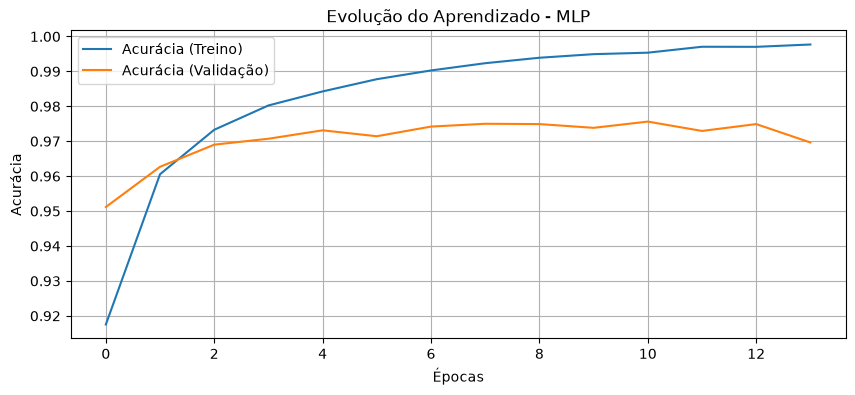


Gerando diagrama arquitetural...


c:\Users\Raphael\Documents\MNIST-Predictive-Pipeline\.venv\Lib\site-packages\visualkeras\layered.py:231: UserWarning: The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.
  warnings.warn("The legend_text_spacing_offset parameter is deprecated and will be removed in a future release.")


In [ ]:
print("--- CONVERTENDO RÓTULOS PARA INTEIROS ---")
y_train = y_train.astype(np.int8)
y_test = y_test.astype(np.int8)
print(f"Tipo atual do y_train: {y_train.dtype}")

print("\n--- CONSTRUINDO A REDE NEURAL (MLP) ---")
# 1. Arquitetura do Modelo
modelo_mlp = Sequential([
    Dense(128, activation='relu', input_shape=(784,)),
    Dense(10, activation='softmax')
])

# 2. Compilação (Regras de Aprendizado)
modelo_mlp.compile(
    optimizer='adam', 
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy']
)
modelo_mlp.summary()

# 3. Treinamento Otimizado com Parada Antecipada
print("\n--- INICIANDO O TREINAMENTO ---")

# Otimização: Trava de segurança contra overfitting
parada_antecipada = EarlyStopping(
    monitor='val_accuracy', 
    patience=3,                 # Tolerância: espera 3 épocas sem melhoria antes de parar
    restore_best_weights=True   # Ao parar, reverte para a época que teve a maior nota
)

historico = modelo_mlp.fit(
    X_train_norm, 
    y_train, 
    epochs=15, 
    batch_size=32,      # <--- A rede neural processará lotes de 32 imagens por vez
    validation_split=0.2,
    callbacks=[parada_antecipada] # Injeção da trava no treinamento
)

# 4. Gráfico de Aprendizado
plt.figure(figsize=(10, 4))
plt.plot(historico.history['accuracy'], label='Acurácia (Treino)')
plt.plot(historico.history['val_accuracy'], label='Acurácia (Validação)')
plt.title('Evolução do Aprendizado - MLP')
plt.xlabel('Épocas')
plt.ylabel('Acurácia')
plt.legend()
plt.grid(True)
plt.show()

# 5. Renderização Arquitetural (VisualKeras)
print("\nGerando diagrama arquitetural...")
for camada in modelo_mlp.layers:
    camada.output_shape = tuple(camada.output.shape)

imagem_vk = visualkeras.layered_view(
    modelo_mlp, 
    to_file='arquitetura_visualkeras.png', 
    scale_xy=2, 
    scale_z=1, 
    max_z=100
)
display(imagem_vk)

### Documentação - Treinamento Rede Neural (MLP)

- Conversão de Tipagem: Os algoritmos do Scikit-Learn realizam a conversão de textos para números internamente, mas o Keras exige tensores numéricos nativos. A conversão das variáveis alvo (`y`) para inteiros de 8 bits (`int8`) adequa os dados para a matemática da rede gastando o mínimo de memória RAM possível.

- Definição da Arquitetura: A topologia do Perceptron Multicamadas (MLP) foi construída de forma direta. A camada oculta recebe as 784 dimensões (pixels) e processa os padrões morfológicos usando 128 neurônios com ativação ReLU (que zera os sinais de pixels inativos de fundo). A camada de saída afunila os cálculos para 10 neurônios, utilizando a função Softmax para converter os sinais brutos em um espectro probabilístico (porcentagem de chance para cada dígito).

- Motor de Compilação: O modelo foi compilado utilizando o otimizador `adam` por sua capacidade de ajustar dinamicamente os saltos matemáticos. A função de perda definida foi a `sparse_categorical_crossentropy`, mandatória para classificar múltiplas categorias quando os gabaritos são números inteiros (não-binarizados).

- Treinamento Dinâmico (Early Stopping): Em vez de forçar o processador a executar as 15 épocas cegamente, o treinamento foi ancorado a um callback de monitoramento. O algoritmo reserva 20% das imagens para validação cega (`validation_split=0.2`). Se a acurácia de validação parar de subir por 3 épocas consecutivas, o treinamento é interrompido e os pesos matemáticos retornam automaticamente para a época de maior desempenho, poupando processamento e blindando o modelo contra overfitting.

- Geração de Relatórios Visuais: O pipeline finaliza plotando as curvas de aprendizado sobrepostas para análise de divergência e aplica um patch de compatibilidade nas propriedades internas do Keras 3 para extrair e exibir o diagrama em blocos 3D das camadas via VisualKeras.

- Exclusão do GridSearchCV: Não usamos a malha de testes automática na Rede Neural devido ao peso computacional. Fazer dezenas de combinações cruzadas treinando 15 épocas repetidas vezes faria o notebook travar ou levar dias para concluir. O ajuste visual pelas curvas de aprendizado foi a solução mais viável e didática.